# Деревья решений

Алгоритм основан на известной структуре данных — деревьях, которые представляют собой последовательные логические условия для разбиения объектов на подгруппы. Условия выбираются таким образом, чтобы объекты, попавшие в правую и левую ветку дерева после разбиения были бы максимально однородные (принадлежали бы одному классу или имели бы одинаковую целевую переменную).

![filled makers](https://drive.google.com/uc?export=view&id=1PDyy51MzGgRWzs5PWDVJS3RcQTLheYII)

В узлах дерева находятся условия разбиения, определяющие, по какому из ребер идти. Все объекты с ответами проходят по дереву, начиная с корневого узла, и заканчивая каким-то листом. В листьях дерево усредняет ответы попавших объектов и это число или класс будет прогнозом для новых объектов. Рассмотрим на примере, как работает дерево решений.

![filled makers](https://drive.google.com/uc?export=view&id=1u1YVdTVsNlk3Ppx0PGQvn7DqGQFB27V8)

Можно потренироваться думать как дерево решений на примерчике ниже. Имеем 10 объектов двух классов (синие vs зеленых). Какие условия лучше выбрать для каждого узла?

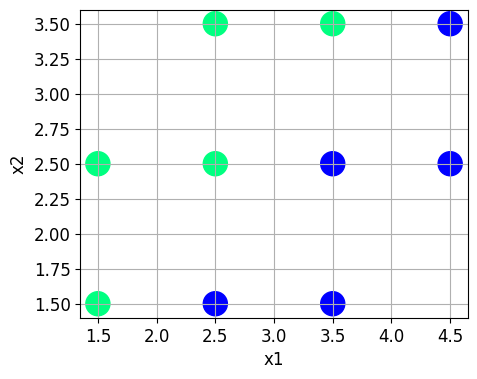

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'font.size': 12, 'figure.figsize': (5,4)})

X = pd.DataFrame({'x1': [1.5, 1.5, 2.5, 2.5, 2.5, 3.5, 3.5, 3.5, 4.5, 4.5],
                  'x2': [1.5, 2.5, 1.5, 2.5, 3.5, 1.5, 2.5, 3.5, 2.5, 3.5]})
y = [1, 1, 0, 1, 1, 0, 0, 1, 0, 0]

plt.scatter('x1', 'x2', data=X, s=300, c=y, marker='o', cmap='winter')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid();

Рассмотрим пример применения дерева решений из библиотеки scikit-learn для синтетических данных. Сгенерируем 100 объектов двух классов. Метка класса равна 0 или 1. У каждого объекта будет два признака (чтобы нарисовать их на проскости).

In [2]:
from matplotlib.colors import ListedColormap
from sklearn import datasets

data, labels = datasets.make_classification(
                    n_samples=100,
                    n_features=2,
                    n_classes=2, n_redundant=0,
                    n_clusters_per_class=1,
                    random_state=5)

In [3]:
labels[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 1])

In [4]:
data[:5]

array([[-0.48221702, -0.28206699],
       [ 1.41747159, -0.86709816],
       [ 0.88378869, -0.92475428],
       [ 0.7469239 , -1.2160026 ],
       [-0.11161925,  0.07390672]])

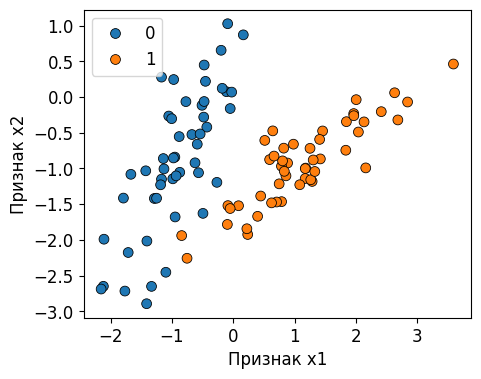

In [5]:
# визуализируем сгенерированные данные
#plt.figure(figsize=(6, 4))
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=labels, s=50,
               edgecolor='black')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2');

Выделим большую часть данных для обучения дереву, а меньшую часть — для проверки его работы. Это называется разбить данные на обучающую выборку (train) и валидационную или тестовую (valid или test).

In [6]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(data,
                                                                    labels,
                                                                    test_size=0.3,
                                                                    random_state=42)

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

# обучаем дерево
tree.fit(train_data, train_labels)

DecisionTreeClassifier(random_state=42)

In [8]:
# Напишем вспомогательную функцию, которая будет возвращать решетку для дальнейшей визуализации
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

def tree_viz(tree, data, labels):
    xx, yy = get_grid(data)
    predicted = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.pcolormesh(xx, yy, predicted, cmap='Set3', alpha=0.9)
    sns.scatterplot(x=data[:, 0], y=data[:, 1],
                hue=labels, s=50, edgecolor='black', legend=None)
    plt.xlabel('Признак x1')
    plt.ylabel('Признак x2');

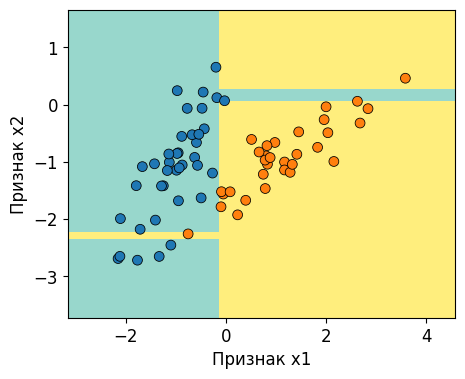

In [9]:
tree_viz(tree, train_data, train_labels)

In [10]:
import graphviz
from sklearn.tree import export_graphviz

def tree_graph(tree, feature_names, class_names):
    dot_data = export_graphviz(tree,
                feature_names=feature_names,
                class_names=class_names,
                filled=True, rounded=True,
                out_file=None)
    graph = graphviz.Source(dot_data)
    return graph

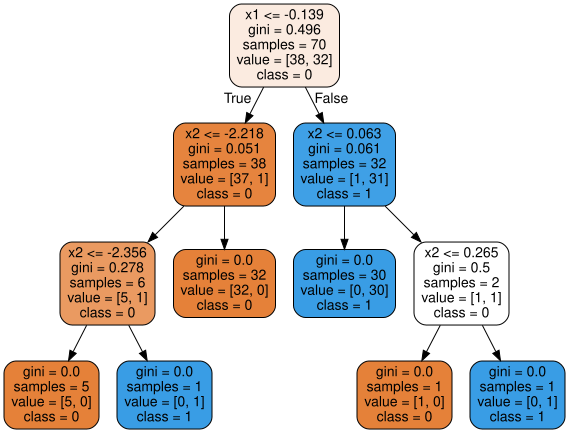

In [11]:
tree_graph(tree, ['x1', 'x2'], ['0', '1'])

В корневой узел попало 70 объектов. Однородность этих объектов оценивается коэффициентом неопределенности Джини (он равен 0, если все объекты одного класса, и максимально равен 0.5 — если объектов разного класса одинаковое количество). Затем было сделано разбиение объектов на 2 группы в зависимости от сравнения признака $x_1$ со значением -0.139 (найдите эту границу на рисунке выше). При этом неопределенность и в левой, и в правой ветке уменьшилась. И так далее, дерево строится до глубины 3. При такой визуализации чем больше объектов одного класса, тем цвет вершины дерева ближе к темно-оранжевому и, наоборот, чем больше объектов второго класса, тем ближе цвет к темно-синему.

### Основные параметры дерева решений

* **max_depth** – максимальная глубина дерева (int, default=None)
* **max_features** – максимальное число признаков, по которым ищется лучшее разбиение в дереве (int, float or {“auto”, “sqrt”, “log2”}, default=None)
* **min_samples_leaf** – минимальное число объектов в листе (int or float, default=1)
* **min_samples_split** - минимальное число объектов для разбиения (int or float, default=2)

Построим дерево глубиной 2 и сравним визуально результаты.

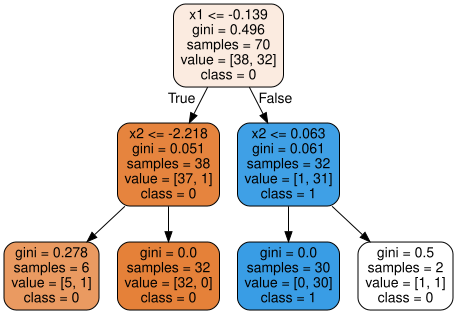

In [12]:
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(train_data, train_labels)
tree_graph(tree2, ['x1', 'x2'], ['0', '1'])

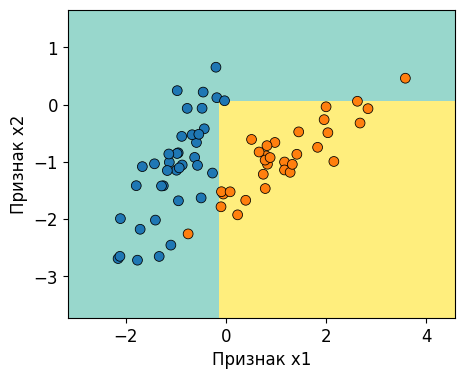

In [13]:
tree_viz(tree2, train_data, train_labels)

Видим, что дерево оставило в покое отдельные объекты, не соответствующие классу большинству. Это позволяет дереву выделить лишь общую закономерность в данных, не переобучаясь. Переобучение – беда деревьев решений. Если дерево ничем не ограничивать, то оно будет идеально описывать обучающую выборку, но на новых данных покажет низкую точность.

**Переобучение (overfitting)** - крайне нежелательное явление, возникающее при решении задач обучения с учителем, когда вероятность ошибки обученного алгоритма на объектах тестовой выборки оказывается существенно выше, чем средняя ошибка на обучающей выборке. Переобучение возникает при использовании избыточно сложных моделей.

**Способы борьбы с переобучением:**

1. Взять больше данных
2. Выбрать более простую модель
3. Использовать регуляризацию

**Регуляризация** - метод борьбы с переобучением с помощью добавления некоторого штрафа за сложность модели.

Ограничим дерево по числу объектов в листе.

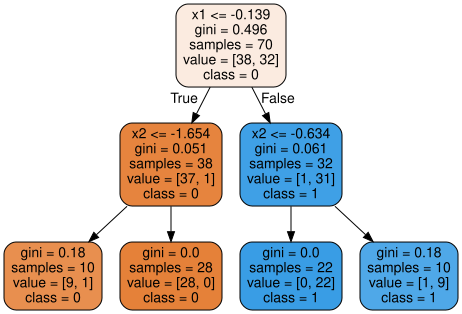

In [14]:
tree3 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
tree3.fit(train_data, train_labels)
tree_graph(tree3, ['x1', 'x2'], ['0', '1'])

Теперь нам надо выбрать показатель (метрику), который оценит точность работы алгоритма.

## Основные метрики задачи классификации

* **Accuracy** – точность. Рассчитывается как отношение количества правильных прогнозов к их общему количеству. Подходит для сбалансированных данных.
* **Precision** – это доля объектов действительно принадлежащих положительному классу относительно всех объектов, которые алгоритм отнес к этому классу.
* **Recall** – это доля найденных алгоритмом объектов положительного класса относительно всех объектов этого класса.
* **F1-score** – среднее между precision и recall.
* **Roc-auc** – площадь под кривой ошибок. Чем ближе к 1, тем точнее алгоритм.

Получим предсказания и сравним точность на трейне и на тесте.

In [15]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_pred = tree.predict(train_data) # предсказания на обучающей выборке
test_pred = tree.predict(test_data) # предсказания на тестовой выборке

print(f'Точность на трейне: {accuracy_score(train_labels, train_pred):.3f}')
print(f'Точность на тесте: {accuracy_score(test_labels, test_pred):.3f}')
print(f'ROC-AUC на тесте: {roc_auc_score(test_labels, test_pred):.3f}')

Точность на трейне: 1.000
Точность на тесте: 0.867
ROC-AUC на тесте: 0.847


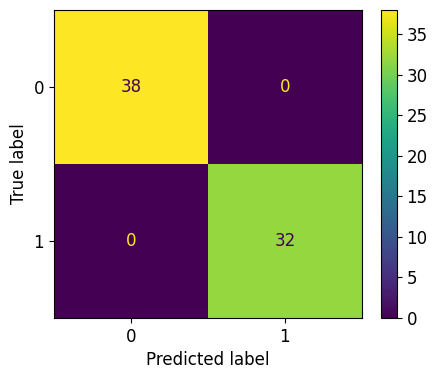

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_train = confusion_matrix(train_labels, train_pred)
cm_test  = confusion_matrix(test_labels, test_pred)

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot();

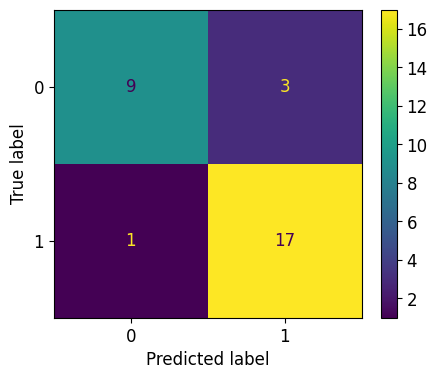

In [17]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot();

Теперь посмотрим точность для ограниченного дерева двумя уровнями.

In [18]:
train_pred_2 = tree2.predict(train_data) # предсказания на обучающей выборке
test_pred_2 = tree2.predict(test_data) # предсказания на тестовой выборке

print(f'Точность на трейне: {accuracy_score(train_labels, train_pred_2):.3f}')
print(f'Точность на тесте: {accuracy_score(test_labels, test_pred_2):.3f}')
print(f'ROC-AUC на тесте: {roc_auc_score(test_labels, test_pred_2):.3f}')

Точность на трейне: 0.971
Точность на тесте: 0.933
ROC-AUC на тесте: 0.931


Точность предсказания ограниченного дерева по числу объектов в листе.

In [19]:
train_pred_3 = tree3.predict(train_data) # предсказания на обучающей выборке
test_pred_3 = tree3.predict(test_data) # предсказания на тестовой выборке

print(f'Точность на трейне: {accuracy_score(train_labels, train_pred_3):.3f}')
print(f'Точность на тесте: {accuracy_score(test_labels, test_pred_3):.3f}')
print(f'ROC-AUC на тесте: {roc_auc_score(test_labels, test_pred_3):.3f}')

Точность на трейне: 0.971
Точность на тесте: 0.833
ROC-AUC на тесте: 0.806


Получили, что дерево решений с двумя уровнями дает точность выше на новых данных, чем дерево без ограничений. Таким образом, мы улучшили алгоритм, немного ослабив его. Это один из способов борьбы с переобучением.

Подбирать оптимальные параметры алгоритма можно, обучая модель с разными значениями и тестируя метрику на отложенной выборке (тестовая выборка).

# Ссылки

[DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

# Задания

1. Сгеренируйте 1000 объектов с 20 признаками и двумя классами (`random_state=1`). Визуализируйте данные. Разбейте данные на обучающую и тестовую выборку (выполнено ниже)
2. Обучите дерево и визуализируйте его. Сколько у дерева получилось уровней и листьев? (3 балла)
3. Проверьте точность на обучающей и тестовой выборках, используя ROC AUC. Наблюдается ли переобучение/недообучение? (3 балла)
4. Подберите (ручками) оптимальные значения параметров `max_depth`, `min_samples_leaf` и `max_features` для достижения максимальной точности (>0.85) на отложенной выборке при отсутствии переобучения. (6 баллов)

In [20]:
seed = 1

X, y = datasets.make_classification(
                    n_samples=1000,
                    n_features=20,
                    n_classes=2, n_redundant=0,
                    n_clusters_per_class=2,
                    random_state=seed)

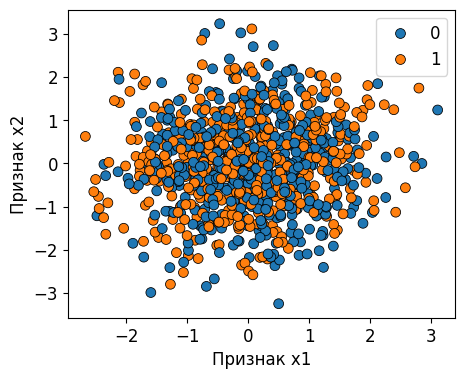

In [21]:
#plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=50,
               edgecolor='black')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2');

In [22]:
# код